# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools
from fractions import Fraction

import sympy as sy
import numpy as np
# for cyclic convolution
from scipy.ndimage import convolve1d

In [2]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution
from cyclic_convolution import agarwal

In [3]:
doc = fitz.open('Parhi - VLSI Digital Signal Processing Systems_ Design and Implementation-Wiley-Interscience (1999).pdf')

The base for this tutorial is the book "VLSI Digital Signal Processing Systems - Design and Implementation" of Keshab K. Parhi.

This tutorial not work with others vector sizes

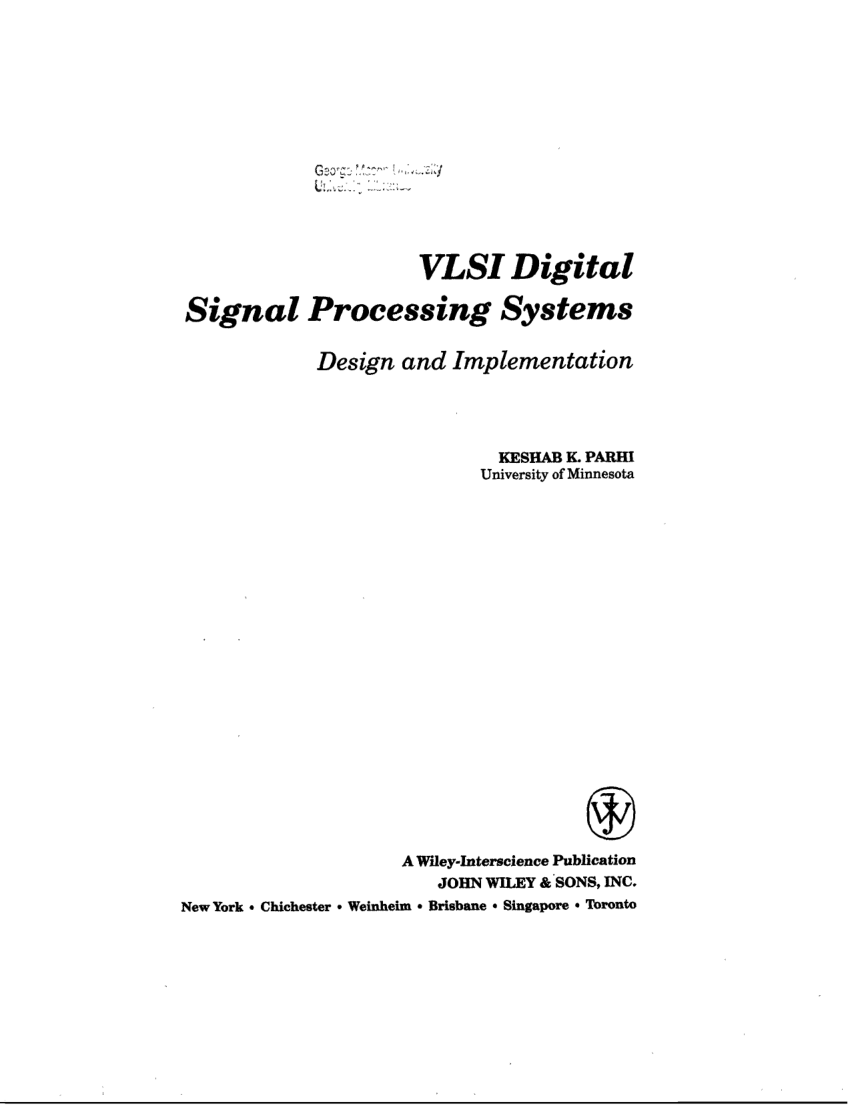

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

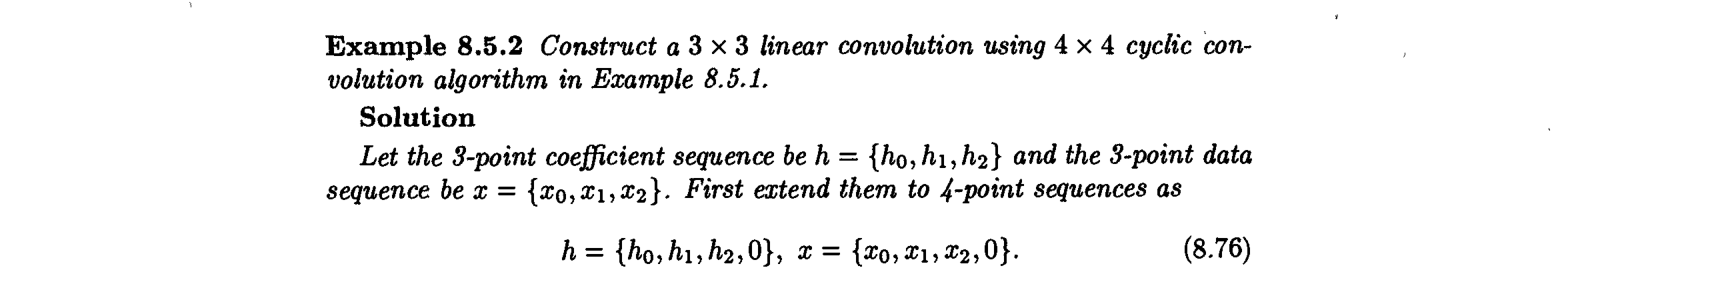

In [5]:
plot_pdf(doc[263], [.36, .49])

Size of vectors

In [6]:
d_num = 7
g_num = 3

In [7]:
n_cyclic = 8

Example of vectors for the convolution

In [8]:
d_values = list(range(1, d_num+1)) + [0] * (n_cyclic - d_num)
g_values = list(range(1, g_num+1)) + [0] * (n_cyclic - g_num)
print(d_values, g_values)

[1, 2, 3, 4, 5, 6, 7, 0] [1, 2, 3, 0, 0, 0, 0, 0]


Polynomial degree

In [9]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

6 2


In [10]:
x = sy.symbols("x")
x

x

In [11]:
di = sy.Matrix(list(sy.symbols(" ".join(f"d_{i}"for i in range(d_num)))) + [0] * (n_cyclic - d_num))
di

Matrix([
[d_0],
[d_1],
[d_2],
[d_3],
[d_4],
[d_5],
[d_6],
[  0]])

In [12]:
sy.symbols(" ".join(f"d_{i}"for i in range(d_num)))

(d_0, d_1, d_2, d_3, d_4, d_5, d_6)

In [13]:
gi = sy.Matrix(list(sy.symbols(" ".join(f"g_{i}"for i in range(g_num)))) + [0] * (n_cyclic - g_num))
gi

Matrix([
[g_0],
[g_1],
[g_2],
[  0],
[  0],
[  0],
[  0],
[  0]])

In [14]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2 + d_3*x**3 + d_4*x**4 + d_5*x**5 + d_6*x**6

In [15]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2

In [16]:
sx = gx*dx
sx

(g_0 + g_1*x + g_2*x**2)*(d_0 + d_1*x + d_2*x**2 + d_3*x**3 + d_4*x**4 + d_5*x**5 + d_6*x**6)

In [17]:
sy.Matrix(np.convolve(di.values(), gi.values()))

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[d_1*g_2 + d_2*g_1 + d_3*g_0],
[d_2*g_2 + d_3*g_1 + d_4*g_0],
[d_3*g_2 + d_4*g_1 + d_5*g_0],
[d_4*g_2 + d_5*g_1 + d_6*g_0],
[          d_5*g_2 + d_6*g_1],
[                    d_6*g_2]])

In [18]:
symmetrical_cyclic_convolution(di, gi)

Matrix([
[          d_0*g_0 + d_6*g_2],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[d_1*g_2 + d_2*g_1 + d_3*g_0],
[d_2*g_2 + d_3*g_1 + d_4*g_0],
[d_3*g_2 + d_4*g_1 + d_5*g_0],
[d_4*g_2 + d_5*g_1 + d_6*g_0],
[          d_5*g_2 + d_6*g_1]])

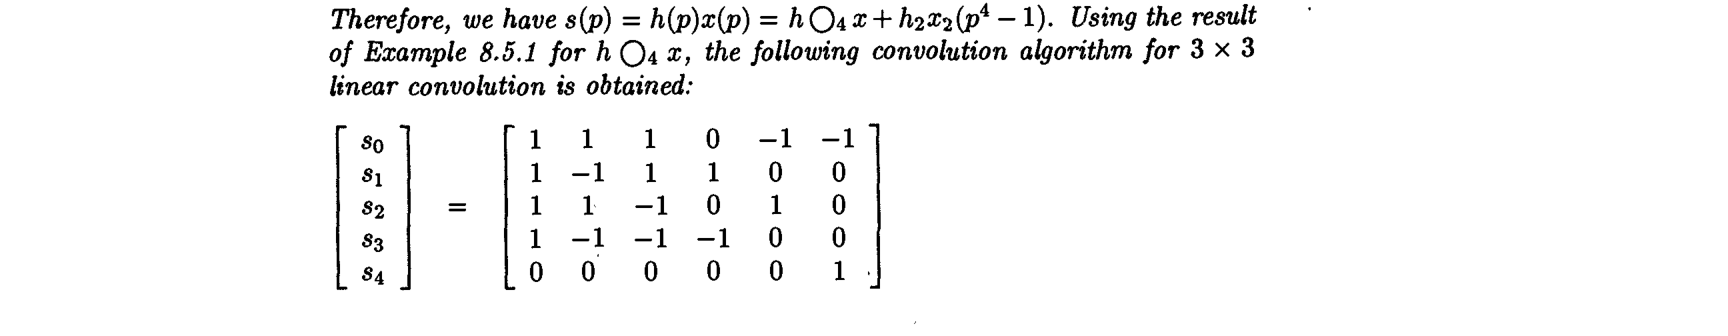

In [19]:
plot_pdf(doc[263], [.7, .85])

In [20]:
lst_c = [m + [n] for m, n in zip(agarwal[n_cyclic]["c"], [-1] + [0] * (len(agarwal[n_cyclic]["c"]) - 1))]
lst_c

[[1, 1, 0, -1, -1, 0, 0, 0, 0, 1, -1, 0, 1, 1, -1],
 [0, -1, 1, 0, 1, -1, 0, 0, 0, 1, 0, 1, -1, 1, 0],
 [1, 1, 0, 0, 0, 0, 1, 1, 0, -1, 1, 0, 1, 1, 0],
 [0, -1, 1, 0, 0, 0, 0, -1, 1, -1, 0, -1, -1, 1, 0],
 [-1, -1, 0, 1, 1, 0, 0, 0, 0, 1, -1, 0, 1, 1, 0],
 [0, 1, -1, 0, -1, 1, 0, 0, 0, 1, 0, 1, -1, 1, 0],
 [-1, -1, 0, 0, 0, 0, -1, -1, 0, -1, 1, 0, 1, 1, 0],
 [0, 1, -1, 0, 0, 0, 0, 1, -1, -1, 0, -1, -1, 1, 0]]

In [21]:
lst_c2 = lst_c + [[0] * (len(lst_c[0]) - 1) + [1]]
lst_c2

[[1, 1, 0, -1, -1, 0, 0, 0, 0, 1, -1, 0, 1, 1, -1],
 [0, -1, 1, 0, 1, -1, 0, 0, 0, 1, 0, 1, -1, 1, 0],
 [1, 1, 0, 0, 0, 0, 1, 1, 0, -1, 1, 0, 1, 1, 0],
 [0, -1, 1, 0, 0, 0, 0, -1, 1, -1, 0, -1, -1, 1, 0],
 [-1, -1, 0, 1, 1, 0, 0, 0, 0, 1, -1, 0, 1, 1, 0],
 [0, 1, -1, 0, -1, 1, 0, 0, 0, 1, 0, 1, -1, 1, 0],
 [-1, -1, 0, 0, 0, 0, -1, -1, 0, -1, 1, 0, 1, 1, 0],
 [0, 1, -1, 0, 0, 0, 0, 1, -1, -1, 0, -1, -1, 1, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]]

In [22]:
len(lst_c2[-1])

15

In [23]:
len(agarwal[n_cyclic]["c"][0])

14

In [24]:
c_mtx = sy.Matrix(lst_c2)
c_mtx

Matrix([
[ 1,  1,  0, -1, -1,  0,  0,  0,  0,  1, -1,  0,  1, 1, -1],
[ 0, -1,  1,  0,  1, -1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[ 1,  1,  0,  0,  0,  0,  1,  1,  0, -1,  1,  0,  1, 1,  0],
[ 0, -1,  1,  0,  0,  0,  0, -1,  1, -1,  0, -1, -1, 1,  0],
[-1, -1,  0,  1,  1,  0,  0,  0,  0,  1, -1,  0,  1, 1,  0],
[ 0,  1, -1,  0, -1,  1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[-1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  1,  0,  1, 1,  0],
[ 0,  1, -1,  0,  0,  0,  0,  1, -1, -1,  0, -1, -1, 1,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 0,  1]])

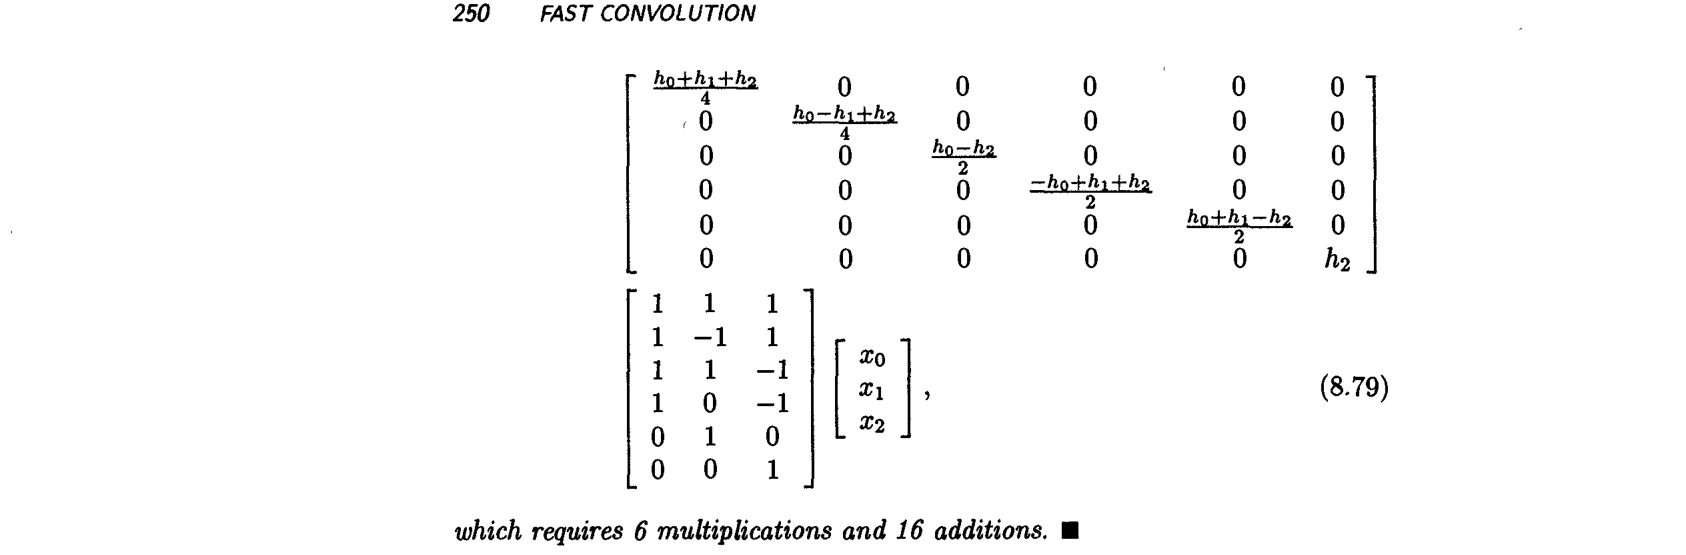

In [25]:
plot_pdf(doc[264], [.15, .4])

In [26]:
a_mtx = sy.Matrix(agarwal[n_cyclic]["a"]  + [d_degree * [0] + [1] + [0] * (len(agarwal[n_cyclic]["a"][0])-1-d_degree)])
a_mtx

Matrix([
[0,  1,  0,  1,  0, -1,  0, -1],
[1, -1,  1, -1, -1,  1, -1,  1],
[1,  0,  1,  0, -1,  0, -1,  0],
[0,  0,  0,  1,  0,  0,  0, -1],
[0,  0,  1, -1,  0,  0, -1,  1],
[0,  0,  1,  0,  0,  0, -1,  0],
[0,  1,  0,  0,  0, -1,  0,  0],
[1, -1,  0,  0, -1,  1,  0,  0],
[1,  0,  0,  0, -1,  0,  0,  0],
[1,  1, -1, -1,  1,  1, -1, -1],
[0,  1,  0, -1,  0,  1,  0, -1],
[1,  0, -1,  0,  1,  0, -1,  0],
[1, -1,  1, -1,  1, -1,  1, -1],
[1,  1,  1,  1,  1,  1,  1,  1],
[0,  0,  0,  0,  0,  0,  1,  0]])

In [27]:
b_mtx = sy.Matrix(agarwal[n_cyclic]["b"]  + [g_degree * [0] + [1] + [0] * (len(agarwal[n_cyclic]["b"][0])-1-g_degree)])
b_mtx

Matrix([
[ 1,  0,  0, -1, -1,  0,  0,  1],
[ 1,  0,  0,  0, -1,  0,  0,  0],
[ 1,  1,  0,  0, -1, -1,  0,  0],
[ 1,  1,  1, -1, -1, -1, -1,  1],
[ 1,  0,  1,  0, -1,  0, -1,  0],
[ 1,  1,  1,  1, -1, -1, -1, -1],
[-1,  1,  1,  1,  1, -1, -1, -1],
[-1,  0,  1,  0,  1,  0, -1,  0],
[-1, -1,  1,  1,  1,  1, -1, -1],
[ 1,  0, -1,  0,  1,  0, -1,  0],
[ 1,  1, -1, -1,  1,  1, -1, -1],
[-1,  1,  1, -1, -1,  1,  1, -1],
[ 1, -1,  1, -1,  1, -1,  1, -1],
[ 1,  1,  1,  1,  1,  1,  1,  1],
[ 0,  0,  1,  0,  0,  0,  0,  0]])

In [28]:
g_mtx = sy.Matrix([sy.Rational(m, n) for m, n in agarwal[n_cyclic]["gq"] + [[1, 1]]])
g_mtx

Matrix([
[1/2],
[1/2],
[1/2],
[1/2],
[1/2],
[1/2],
[1/2],
[1/2],
[1/2],
[1/4],
[1/4],
[1/4],
[1/8],
[1/8],
[  1]])

In [29]:
bg_mtx = sy.diag(*(np.multiply(b_mtx, g_mtx)*gi).tolist())
bg_mtx

Matrix([
[g_0/2,     0,             0,                     0,             0,                     0,                      0,              0,                      0,             0,                     0,                      0,                     0,                     0,   0],
[    0, g_0/2,             0,                     0,             0,                     0,                      0,              0,                      0,             0,                     0,                      0,                     0,                     0,   0],
[    0,     0, g_0/2 + g_1/2,                     0,             0,                     0,                      0,              0,                      0,             0,                     0,                      0,                     0,                     0,   0],
[    0,     0,             0, g_0/2 + g_1/2 + g_2/2,             0,                     0,                      0,              0,                      0,             0,               

In [30]:
bg_mtx.shape

(15, 15)

In [31]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s

Matrix([
[ 1,  1,  0, -1, -1,  0,  0,  0,  0,  1, -1,  0,  1, 1, -1],
[ 0, -1,  1,  0,  1, -1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[ 1,  1,  0,  0,  0,  0,  1,  1,  0, -1,  1,  0,  1, 1,  0],
[ 0, -1,  1,  0,  0,  0,  0, -1,  1, -1,  0, -1, -1, 1,  0],
[-1, -1,  0,  1,  1,  0,  0,  0,  0,  1, -1,  0,  1, 1,  0],
[ 0,  1, -1,  0, -1,  1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[-1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  1,  0,  1, 1,  0],
[ 0,  1, -1,  0,  0,  0,  0,  1, -1, -1,  0, -1, -1, 1,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 0,  1]])*Matrix([
[g_0/2,     0,             0,                     0,             0,                     0,                      0,              0,                      0,             0,                     0,                      0,                     0,                     0,   0],
[    0, g_0/2,             0,                     0,             0,                     0,                      0,              0,                      0,         

## Example

In [32]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d_0: 1,
 d_1: 2,
 d_2: 3,
 d_3: 4,
 d_4: 5,
 d_5: 6,
 d_6: 7,
 0: 0,
 g_0: 1,
 g_1: 2,
 g_2: 3}

In [33]:
si = s.subs(subs)
si

Matrix([
[ 1,  1,  0, -1, -1,  0,  0,  0,  0,  1, -1,  0,  1, 1, -1],
[ 0, -1,  1,  0,  1, -1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[ 1,  1,  0,  0,  0,  0,  1,  1,  0, -1,  1,  0,  1, 1,  0],
[ 0, -1,  1,  0,  0,  0,  0, -1,  1, -1,  0, -1, -1, 1,  0],
[-1, -1,  0,  1,  1,  0,  0,  0,  0,  1, -1,  0,  1, 1,  0],
[ 0,  1, -1,  0, -1,  1,  0,  0,  0,  1,  0,  1, -1, 1,  0],
[-1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  1,  0,  1, 1,  0],
[ 0,  1, -1,  0,  0,  0,  0,  1, -1, -1,  0, -1, -1, 1,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 0,  1]])*Matrix([
[1/2,   0,   0, 0, 0, 0, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0, 1/2,   0, 0, 0, 0, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0, 3/2, 0, 0, 0, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0,   0, 3, 0, 0, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0,   0, 0, 2, 0, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0,   0, 0, 0, 3, 0, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0,   0, 0, 0, 0, 2, 0, 0,    0, 0, 0,   0,   0, 0],
[  0,   0,  

In [34]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_0*g_2*x**2 + d_1*g_0*x + d_1*g_1*x**2 + d_1*g_2*x**3 + d_2*g_0*x**2 + d_2*g_1*x**3 + d_2*g_2*x**4 + d_3*g_0*x**3 + d_3*g_1*x**4 + d_3*g_2*x**5 + d_4*g_0*x**4 + d_4*g_1*x**5 + d_4*g_2*x**6 + d_5*g_0*x**5 + d_5*g_1*x**6 + d_5*g_2*x**7 + d_6*g_0*x**6 + d_6*g_1*x**7 + d_6*g_2*x**8

Let's compare the output polynomial matrix from direct and winograd method

In [35]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)
se

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[d_1*g_2 + d_2*g_1 + d_3*g_0],
[d_2*g_2 + d_3*g_1 + d_4*g_0],
[d_3*g_2 + d_4*g_1 + d_5*g_0],
[d_4*g_2 + d_5*g_1 + d_6*g_0],
[          d_5*g_2 + d_6*g_1],
[                    d_6*g_2]])

Comparing numerical outputs from direct and winograd method

In [36]:
se.subs(subs)

Matrix([
[ 1],
[ 4],
[10],
[16],
[22],
[28],
[34],
[32],
[21]])

In [37]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[ 1],
[ 4],
[10],
[16],
[22],
[28],
[34],
[32],
[21],
[ 0],
[ 0],
[ 0],
[ 0],
[ 0],
[ 0]])